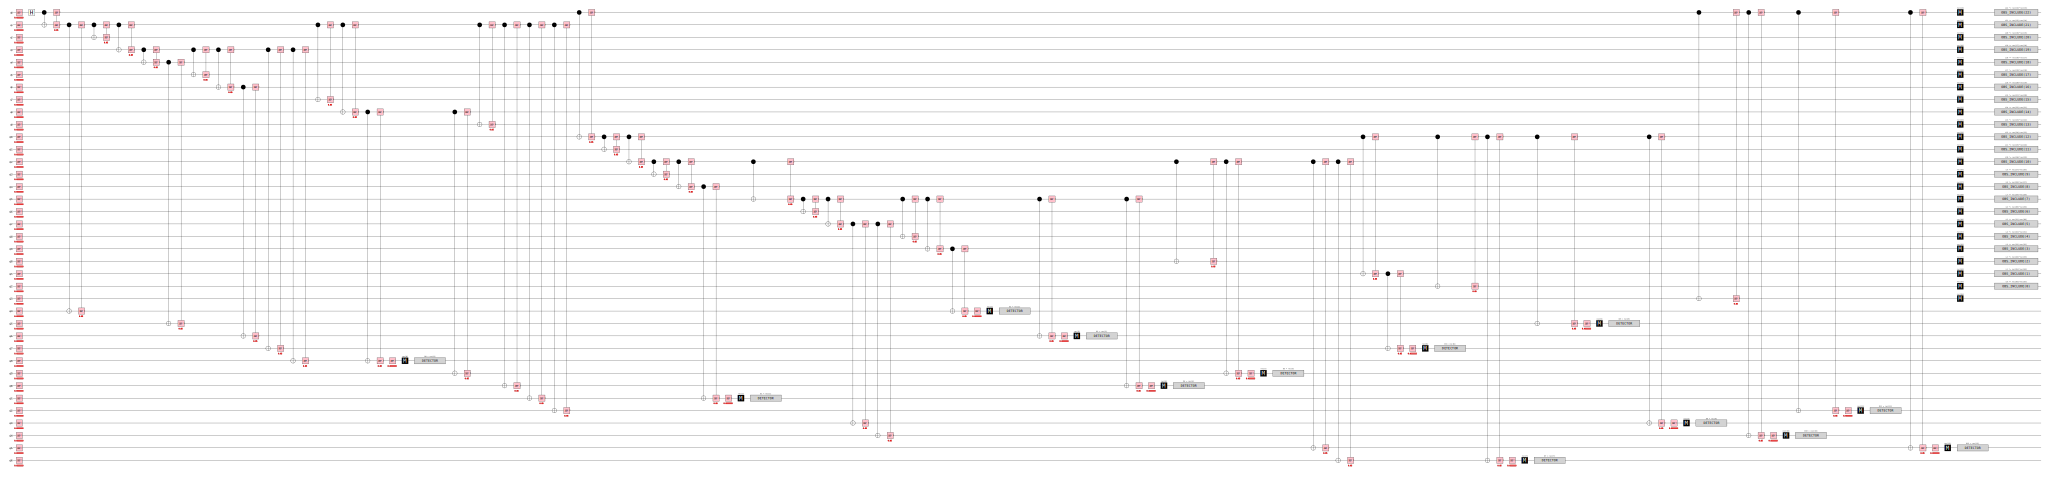

In [1]:
from spidercat.simulate import add_measurements
from spidercat.circuit_extraction import make_stim_circ_noisy

import stim

n = 24
p = 0.05
with open(f"../spidercat/circuits/cat_state_t5_n{n}_p1.stim", "r") as f:
    circ = stim.Circuit(f.read())

noisy_circ = make_stim_circ_noisy(circ, p_2=p, p_init=2 / 3 * p, p_meas=2 / 3 * p, p_mem=0)
add_measurements(noisy_circ, n, "spider-cat")
for i in range(n - 1):
    noisy_circ.append("OBSERVABLE_INCLUDE", [stim.target_rec(-1 - i), stim.target_rec(-2 - i)],i)

noisy_circ.diagram('timeline-svg')

In [2]:
import os
import tesseract_decoder
import tesseract_decoder.tesseract as tesseract
import numpy as np

from contextlib import contextmanager

@contextmanager
def suppress_c_stdout_stderr():
    # Open a dummy file to route the output into the void
    devnull = os.open(os.devnull, os.O_WRONLY)

    # Save the actual file descriptors for stdout (1) and stderr (2)
    old_stdout = os.dup(1)
    old_stderr = os.dup(2)

    try:
        # Overwrite stdout and stderr with devnull
        os.dup2(devnull, 1)
        os.dup2(devnull, 2)
        yield
    finally:
        # Restore the original stdout and stderr
        os.dup2(old_stdout, 1)
        os.dup2(old_stderr, 2)

        # Clean up the file descriptors
        os.close(devnull)
        os.close(old_stdout)
        os.close(old_stderr)


def get_num_errors(observables):
    num_shots = observables.shape[0]
    n = observables.shape[1] + 1
    relative_errors = np.cumsum(observables, axis=1) % 2
    zeros_column = np.zeros((num_shots, 1), dtype=int)
    full_error_strings = np.hstack((zeros_column, relative_errors))
    weight_ones = np.sum(full_error_strings, axis=1)
    return np.minimum(weight_ones, n - weight_ones)


def run_tesseract_decoder(decoder, dets, obs):
    print("Raw Samples")
    print(f"Average number of qubit-flips: {np.average(get_num_errors(obs)):.2f}")
    print(f"Probability of more than 5 qubit-flips: {np.average(get_num_errors(obs) > 5):.2%}")
    print()
    print("Post-Selected Samples")
    print(f"Average number of qubit-flips: {np.average(get_num_errors(obs[~np.any(dets, axis=1)])):.2f}")
    print(f"Probability of more than 5 qubit-flips: {np.average(get_num_errors(obs[~np.any(dets, axis=1)]) > 5):.2%}")
    print()
    obs_predicted = decoder.decode_batch(dets)
    print("Decoded Samples")
    print(f"Average number of qubit-flips: {np.average(get_num_errors(obs_predicted != obs)):.2f}")
    print(f"Probability of more than 5 qubit-flips: {np.average(get_num_errors(obs_predicted != obs) > 5):.2%}")


num_shots = 100_000
sampler = noisy_circ.compile_detector_sampler()
detector_outcomes, actual_observables = sampler.sample(shots=num_shots, separate_observables=True)
dem = noisy_circ.detector_error_model(decompose_errors=True)


# setup the tesseract decoder configuration
tesseract_config = tesseract.TesseractConfig(
    dem=dem,
    pqlimit=10000,
    no_revisit_dets=True,
    # verbose=True,
    det_orders=tesseract_decoder.utils.build_det_orders(
        dem, num_det_orders=1,
        method=tesseract_decoder.utils.DetOrder.DetIndex,
        seed=2384753),
)

with suppress_c_stdout_stderr():
    tesseract_dec = tesseract_config.compile_decoder()

results = run_tesseract_decoder(tesseract_dec, detector_outcomes, actual_observables)

Raw Samples
Average number of qubit-flips: 4.11
Probability of more than 5 qubit-flips: 30.56%

Post-Selected Samples
Average number of qubit-flips: 0.61
Probability of more than 5 qubit-flips: 0.02%

Decoded Samples
Average number of qubit-flips: 1.89
Probability of more than 5 qubit-flips: 5.62%
